In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
mode = 'SyntheticBanding'
model_dir = "D:/DeepSSFP/"
model_name="knee_study"

100%|██████████| 4/4 [00:09<00:00,  2.43s/it]


Dataset loaded: (320, 416, 416, 8)
Memory size: 0.88604672 GB
Dataset shape: (320, 416, 416, 8)
Formatting data for SyntheticBanding mode...
Data format complete.
Input shape: (320, 416, 416, 4), Output shape: (320, 416, 416, 4)
Selected indices: [303 289]
Figure size: (8, 4)


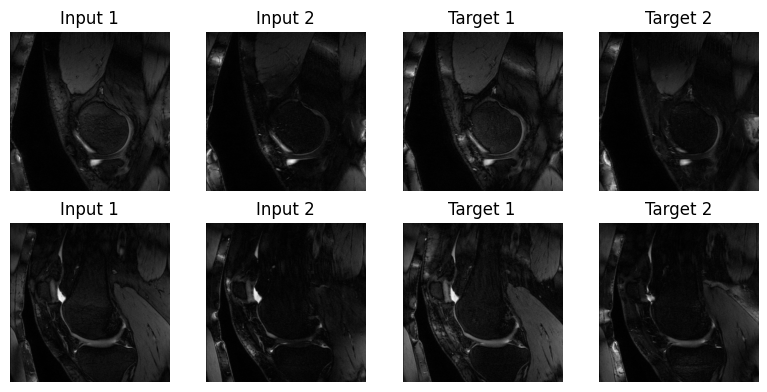

In [3]:
import deepssfp.dataloader
import deepssfp.dataformatter

path = 'D:/MRI/2024_Krithika_KneeStudy'

filters = ['HV9_lk_r1', 'HV9_lk_r2', 'HV9_rk_r1', 'HV9_rk_r2']

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters, data_format='RealImag')
print(f"Dataset shape: {dataset['M'].shape}")
input, output = deepssfp.dataformatter.format_synthetic_banding_for_realimag_data(dataset['M'])
print(f"Input shape: {input.shape}, Output shape: {output.shape}")

deepssfp.visualize_images(
    input_images=input,
    target_images=output,
    num_samples=2,
)

In [4]:
stats = np.load('D:/DeepSSFP/knee_study_syntheticbanding_scaler.npy', allow_pickle=True)
mean = stats[0]
std = stats[1]
scaler = deepssfp.dataset.StandardScaler(np.ones((1,1)), mean=mean, std=std)

#del dataset
ds = deepssfp.Dataset('SyntheticBanding', input_data=input, output_data=output, ratio=0, stats_faction=1.0, scaler=scaler)

Info: Data all ready formated.
Dataset: mode:SyntheticBanding, size:320 height:416 width:416 cin:4 cout:4 ratio:0
dtype: float16, float16
Using provided scaler



===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/knee_study_syntheticbanding
Dataset path: D:/DeepSSFP/knee_study_dataset.npy
Info: dataset (ds) already loaded.
Training data shape: (0, 416, 416, 4), (0, 416, 416, 4)
Input scaler stats: mean=-0.0398, std=25.3446
Output scaler stats: mean=-0.0398, std=25.3446
Selected indices: [ 25 121  15]
Figure size: (8, 6)


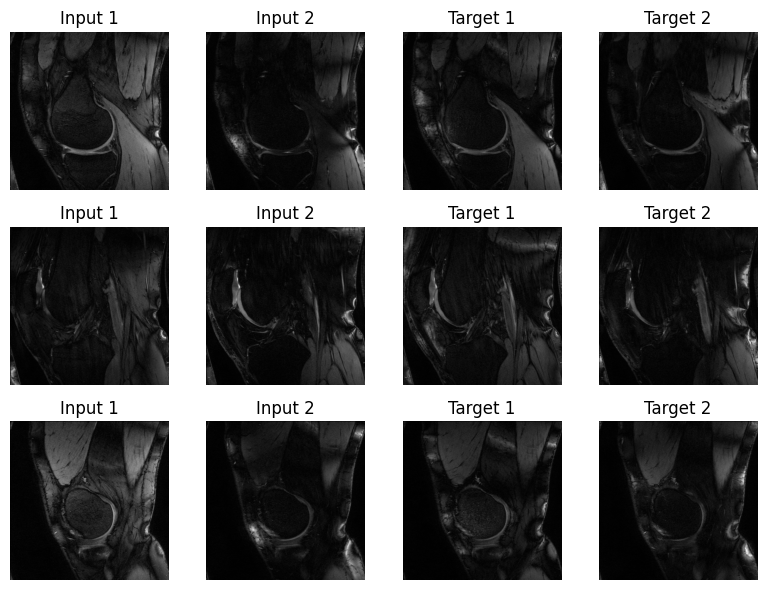

2025-04-08 14:08:23,350 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/knee_study_syntheticbanding



Loading pre-trained model...


In [ ]:
import deepssfp.analysis
results = deepssfp.analysis.run_training(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=False,
    ds=ds,
    #custom_dataset=dataset,
    save_dataset=False,
)

In [ ]:
print(ds.x_train.shape, ds.x_test.shape)


(0, 416, 416, 4) (320, 416, 416, 4)


2025-04-08 14:01:17,744 - DeepSSFP - INFO - Making predictions on data with shape (320, 416, 416, 4)
2025-04-08 14:01:20,406 - DeepSSFP - INFO - Predictions complete. Output shape: (320, 416, 416, 4)


Selected indices: [94 98]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/knee_study_syntheticbanding_prediction_results.png


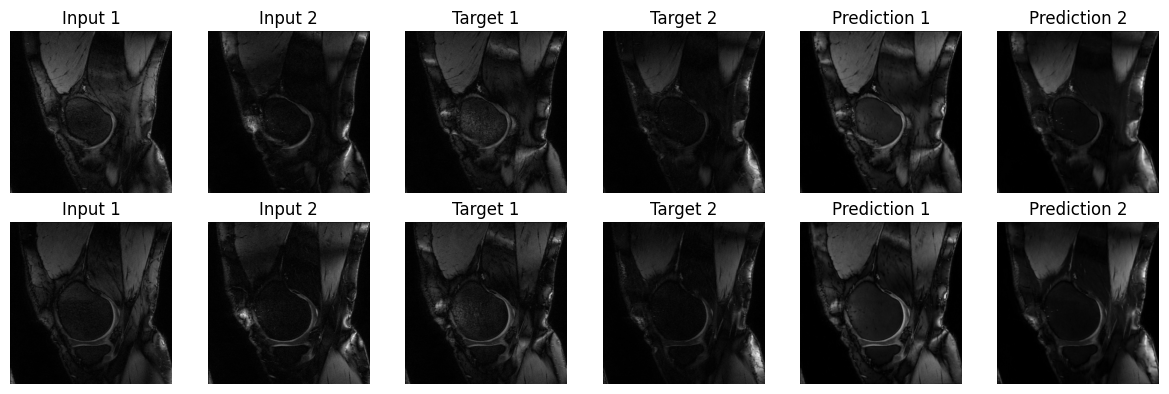

In [ ]:
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")

# Generate predictions
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.outputScaler.inverse_transform(deepssfp.predict(results['model'], ds.x_test))

# Visualize results
deepssfp.visualize_images(
    input_images=x_test,
    target_images=y_test,
    predicted_images=predictions,
    num_samples=2,
    save_path=f"{path}_prediction_results.png"
)

In [ ]:
x_test.shape

(320, 416, 416, 4)

In [ ]:
#test_path =f"{path}_test_predictions"
#np.save(test_path, [{'input':x_test, 'target':y_test, 'prediction':predictions}])

In [17]:
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")

test_path =f"{path}_test_predictions"
saved_data = np.load(test_path+'.npy', allow_pickle=True)[0]
input = saved_data['input']
target = saved_data['target']
predictions = saved_data['prediction']
print(target.shape, predictions.shape)

(320, 416, 416, 4) (320, 416, 416, 4)


In [9]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt

def compare_images(target, estimated):
    """
    Calculate various metrics to compare target and estimated images.
    
    Parameters:
    -----------
    target : numpy.ndarray
        The ground truth or target 2D image
    estimated : numpy.ndarray
        The estimated or predicted 2D image
    
    Returns:
    --------
    dict
        Dictionary containing comparison metrics
    """
    # Ensure both images have the same shape
    if target.shape != estimated.shape:
        raise ValueError(f"Images must have the same shape. Got {target.shape} and {estimated.shape}")
    
    # Calculate pixel-wise difference
    diff = target - estimated
    
    # Basic statistics of the difference
    metrics = {
        'mean_error': np.mean(diff),
        'mean_absolute_error': np.mean(np.abs(diff)),
        'mean_squared_error': np.mean(np.square(diff)),
        'root_mean_squared_error': np.sqrt(np.mean(np.square(diff))),
        'max_error': np.max(np.abs(diff)),
        'min_error': np.min(np.abs(diff)),
        'std_error': np.std(diff),
    }
    
    # Calculate normalized metrics (if images are not binary)
    if np.max(target) > 1 or np.max(estimated) > 1:
        # Assume images are in range [0, 255]
        max_val = 255.0
    else:
        # Assume images are normalized in range [0, 1]
        max_val = 1.0
    
    # Calculate PSNR (Peak Signal-to-Noise Ratio)
    # Higher is better, typical values are between 20 and 40
    metrics['psnr'] = psnr(target, estimated, data_range=max_val)
    
    # Calculate SSIM (Structural Similarity Index)
    # Ranges from -1 to 1, where 1 means perfect similarity
    metrics['ssim'] = ssim(target, estimated, data_range=max_val)
    
    # Calculate correlation coefficient
    # Ranges from -1 to 1, where 1 means perfect correlation
    if np.std(target) > 0 and np.std(estimated) > 0:  # Avoid division by zero
        metrics['correlation'] = np.corrcoef(target.flatten(), estimated.flatten())[0, 1]
    else:
        metrics['correlation'] = np.nan
    
    return metrics

def visualize_comparison(target, estimated, title=None):
    """
    Visualize the target, estimated, and difference images.
    
    Parameters:
    -----------
    target : numpy.ndarray
        The ground truth or target 2D image
    estimated : numpy.ndarray
        The estimated or predicted 2D image
    title : str, optional
        Title for the plot
    """
    diff = target - estimated
    abs_diff = np.abs(diff)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Target image
    im0 = axes[0, 0].imshow(target, cmap='viridis')
    axes[0, 0].set_title('Target Image')
    plt.colorbar(im0, ax=axes[0, 0])
    
    # Estimated image
    im1 = axes[0, 1].imshow(estimated, cmap='viridis')
    axes[0, 1].set_title('Estimated Image')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # Difference image
    im2 = axes[1, 0].imshow(diff, cmap='RdBu_r')
    axes[1, 0].set_title('Difference (Target - Estimated)')
    plt.colorbar(im2, ax=axes[1, 0])
    
    # Absolute difference image
    im3 = axes[1, 1].imshow(abs_diff, cmap='hot')
    axes[1, 1].set_title('Absolute Difference')
    plt.colorbar(im3, ax=axes[1, 1])
    
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.tight_layout()
    return fig

# Example usage:
"""
# Creating sample data
target = np.random.rand(100, 100)
estimated = target + 0.1 * np.random.randn(100, 100)  # Add some noise

# Calculate metrics
metrics = compare_images(target, estimated)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

# Visualize the comparison
fig = visualize_comparison(target, estimated, "Comparison of Target and Estimated Images")
plt.show()
"""

'\n# Creating sample data\ntarget = np.random.rand(100, 100)\nestimated = target + 0.1 * np.random.randn(100, 100)  # Add some noise\n\n# Calculate metrics\nmetrics = compare_images(target, estimated)\nfor metric, value in metrics.items():\n    print(f"{metric}: {value}")\n\n# Visualize the comparison\nfig = visualize_comparison(target, estimated, "Comparison of Target and Estimated Images")\nplt.show()\n'

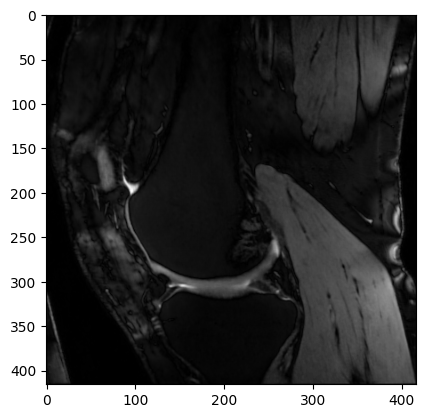

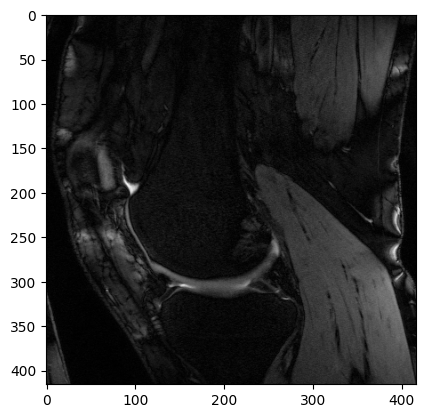

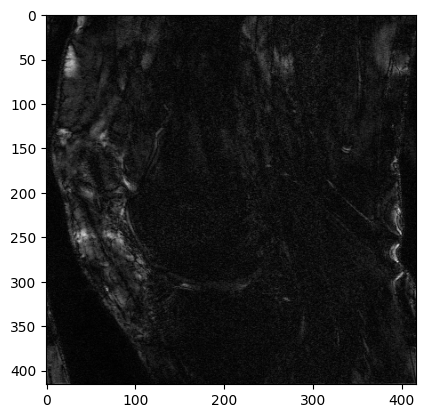

mean_error: 5.853978530573948
mean_absolute_error: 8.18049216550593
mean_squared_error: 142.12509961945278
root_mean_squared_error: 11.921623195666468
max_error: 132.1480304456361
min_error: 9.764483077390196e-05
std_error: 10.385376015486012
psnr: 26.604095787628776
ssim: 0.6574387194315857
correlation: 0.9442089356710026


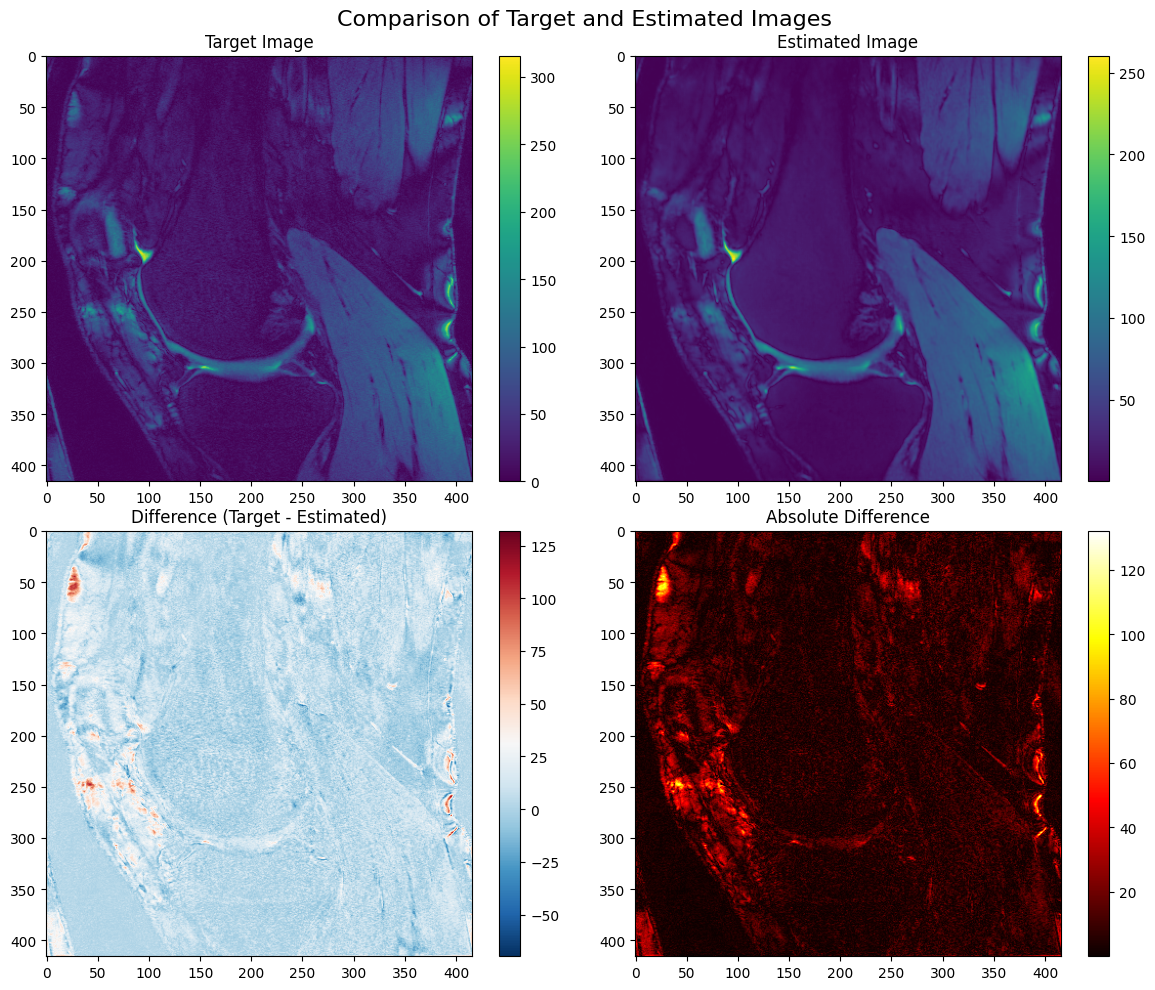

mean_error: -0.0073275231420207925
mean_absolute_error: 0.8963790001175064
mean_squared_error: 2.6510814181917746
root_mean_squared_error: 1.6282141806874717
max_error: 6.276214582800769
min_error: 4.957968927354894e-06
std_error: 1.6281976924183308
psnr: 43.89657295176144
ssim: 0.9064519469255459
correlation: 0.5412106634177865


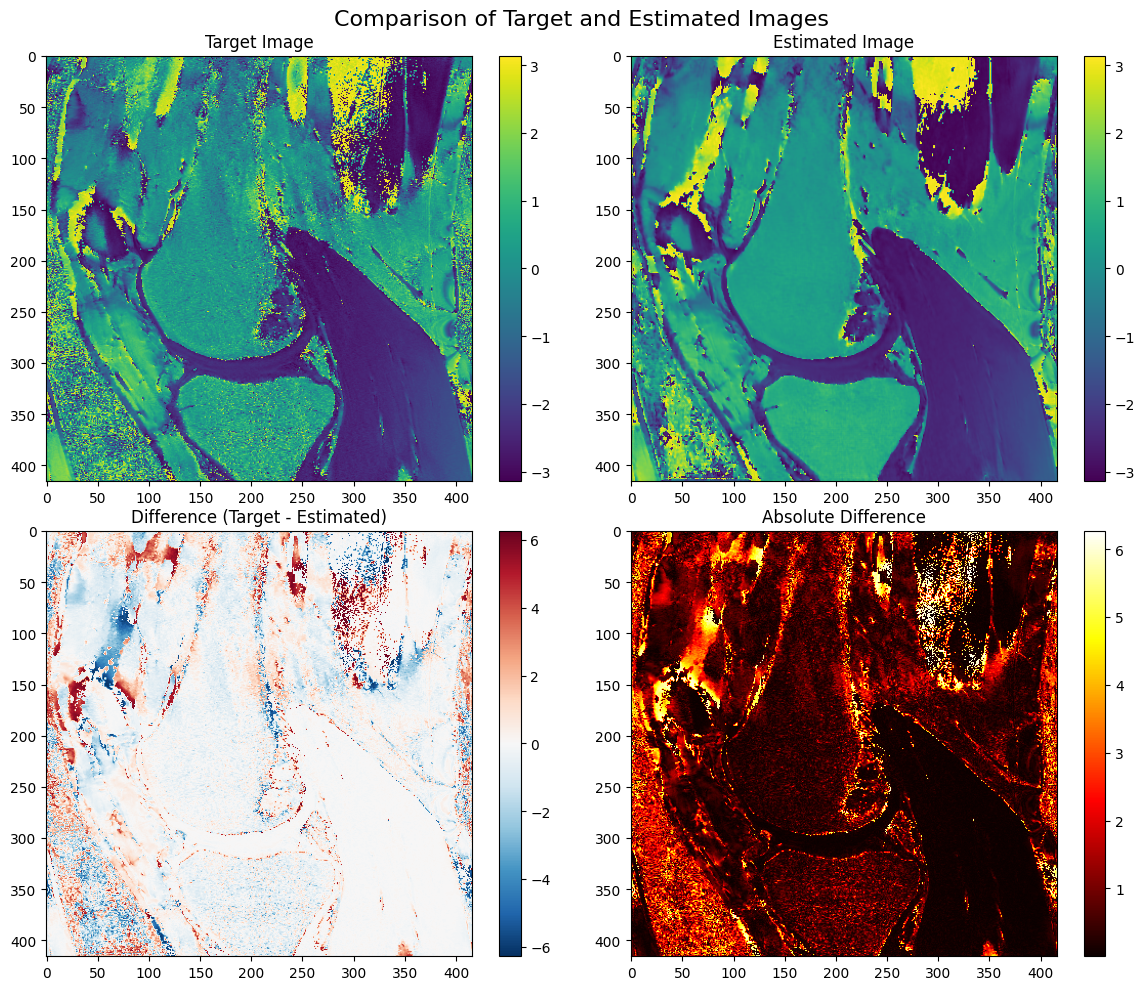

In [18]:
pred_complex = deepssfp.from_pairs_to_complex(predictions)
target_complex = deepssfp.from_pairs_to_complex(target)
idx = 30 
plt.imshow(np.abs(pred_complex[idx,:,:,0]), cmap='gray')
plt.show()

plt.imshow(np.abs(target_complex[idx,:,:,0]), cmap='gray')
plt.show()

plt.imshow(np.abs(pred_complex[idx,:,:,0] - target_complex[idx,:,:,0]), cmap='gray')
plt.show()

# Calculate metrics
_target = np.abs(target_complex[idx,:,:,0])
_estimated = np.abs(pred_complex[idx,:,:,0])
metrics = compare_images(_target, _estimated)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

# Visualize the comparison
fig = visualize_comparison(_target, _estimated, "Comparison of Target and Estimated Images")
plt.show()

_target = np.angle(target_complex[idx,:,:,0])
_estimated = np.angle(pred_complex[idx,:,:,0])
metrics = compare_images(_target, _estimated)
for metric, value in metrics.items():
    print(f"{metric}: {value}")

# Visualize the comparison
fig = visualize_comparison(_target, _estimated, "Comparison of Target and Estimated Images")
plt.show()